# **Analisis y Exploracion de Datos Sensor CONAGUA**

### **Alumno:** Cazarez Garcia Luis Gustavo  
### **Clase:** Ciencia de Datos  
### **Maestro:** Mora Felix Zuriel Dathan

# **1.- Preparacion de los datos**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargar dataset

archivo = 'data.csv'

datos = pd.read_csv(archivo)

print(datos.head())

      PERIODO  CVE_ENT              ENTIDAD  MINIMA  MEDIA  MAXIMA  \
0  1985-01-01        0             Nacional     7.8   15.9    23.9   
1  1985-01-01        1       Aguascalientes     3.1   12.2    21.3   
2  1985-01-01        2      Baja California     5.6   12.9    20.2   
3  1985-01-01        3  Baja California Sur     9.2   17.1    25.0   
4  1985-01-01        4             Campeche    15.7   22.7    29.7   

   PRECIPITACION  
0           36.0  
1            4.9  
2           12.2  
3           30.3  
4           20.9  


In [4]:
# Revisar columnas del dataset

print(datos.columns)

Index(['PERIODO', 'CVE_ENT', 'ENTIDAD', 'MINIMA', 'MEDIA', 'MAXIMA',
       'PRECIPITACION'],
      dtype='str')


In [5]:
# Seleccionar columna de temperatura media

temperatura = datos['MEDIA']

# Eliminar valores vacios

temperatura = temperatura.dropna()

print(temperatura.head())

0    15.9
1    12.2
2    12.9
3    17.1
4    22.7
Name: MEDIA, dtype: float64


# **2.- Analisis estadistico descriptivo**

In [7]:
# Calculo de medidas estadisticas

media = temperatura.mean()

mediana = temperatura.median()

moda = temperatura.mode()[0]

minimo = temperatura.min()

maximo = temperatura.max()

rango = maximo - minimo

varianza = temperatura.var()

desviacion = temperatura.std()

print('RESULTADOS')
print(f'Media: {media:.2f}')
print(f'Mediana: {mediana:.2f}')
print(f'Moda: {moda:.2f}')
print(f'Minimo: {minimo:.2f}')
print(f'Maximo: {maximo:.2f}')
print(f'Rango: {rango:.2f}')
print(f'Varianza: {varianza:.2f}')
print(f'Desviacion estandar: {desviacion:.2f}')

RESULTADOS
Media: 21.40
Mediana: 21.70
Moda: 24.60
Minimo: 7.50
Maximo: 33.40
Rango: 25.90
Varianza: 22.95
Desviacion estandar: 4.79


## **Interpretacion de resultados**

In [8]:
print('INTERPRETACION')

print('\nDesviacion estandar')

if desviacion > 5:
    print('Existe una dispersion considerable en los datos climaticos.')

else:
    print('Los datos presentan una dispersion moderada.')

print('\nComparacion entre media y mediana')

if media > mediana:
    print('La distribucion presenta sesgo hacia la derecha.')

elif media < mediana:
    print('La distribucion presenta sesgo hacia la izquierda.')

else:
    print('La distribucion es aproximadamente simetrica.')

INTERPRETACION

Desviacion estandar
Los datos presentan una dispersion moderada.

Comparacion entre media y mediana
La distribucion presenta sesgo hacia la izquierda.


## **Deteccion de valores atipicos**

In [9]:
Q1 = temperatura.quantile(0.25)

Q3 = temperatura.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR

limite_superior = Q3 + 1.5 * IQR

outliers = temperatura[
    (temperatura < limite_inferior) |
    (temperatura > limite_superior)
]

print('Cantidad de outliers encontrados:')

print(len(outliers))

print('\nPrimeros outliers:')

print(outliers.head())

Cantidad de outliers encontrados:
0

Primeros outliers:
Series([], Name: MEDIA, dtype: float64)


# **3.- Construccion de graficas**

## Histograma

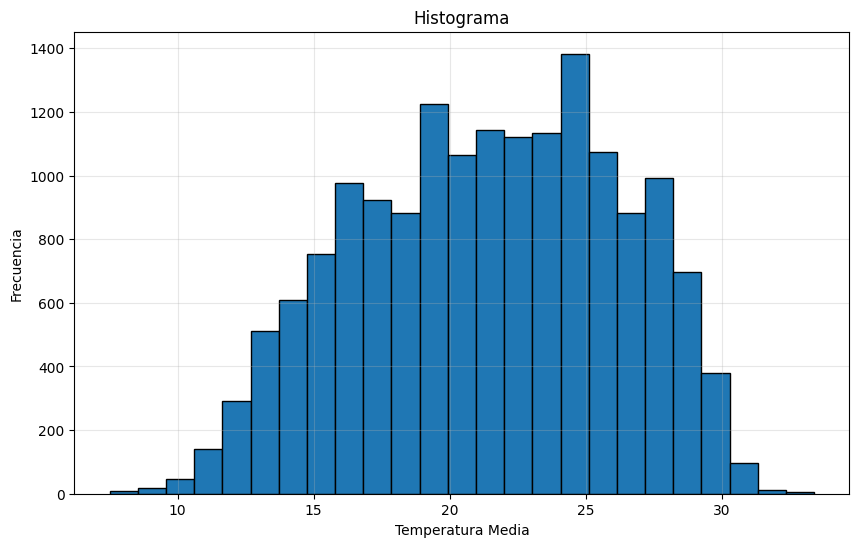

In [12]:
plt.figure(figsize=(10,6))

plt.hist(
    temperatura,
    bins=25,
    edgecolor='black'
)

plt.title('Histograma')

plt.xlabel('Temperatura Media')

plt.ylabel('Frecuencia')

plt.grid(alpha=0.3)

plt.show()

In [11]:
print('HISTOGRAMA')

print('El histograma muestra la distribucion de las temperaturas medias registradas.')

print('La mayor concentracion de datos se encuentra cerca de la media.')

print('La distribucion presenta un ligero sesgo hacia la izquierda debido a que la media es menor que la mediana.')

print('No se observan concentraciones extremas ni multimodalidad importante.')

print('La dispersion observada coincide con el valor moderado de la desviacion estandar.')

HISTOGRAMA
El histograma muestra la distribucion de las temperaturas medias registradas.
La mayor concentracion de datos se encuentra cerca de la media.
La distribucion presenta un ligero sesgo hacia la izquierda debido a que la media es menor que la mediana.
No se observan concentraciones extremas ni multimodalidad importante.
La dispersion observada coincide con el valor moderado de la desviacion estandar.


## Grafica de densidad

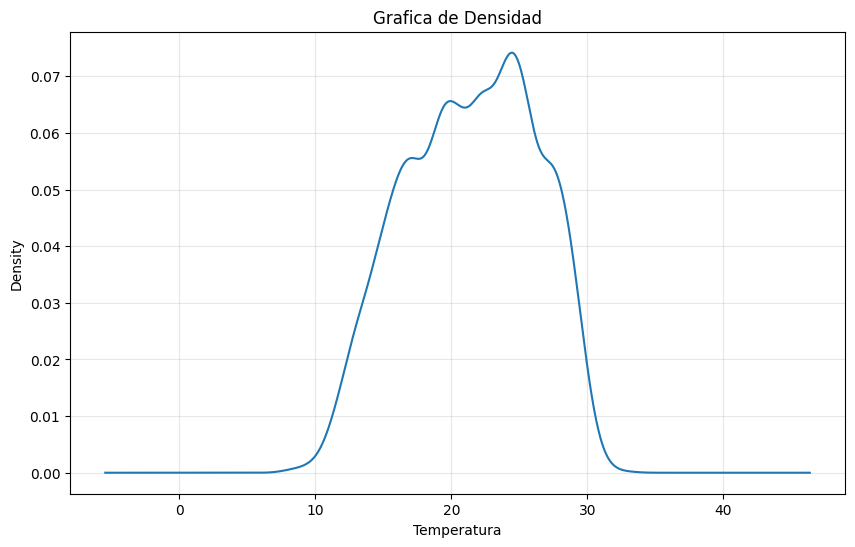

In [13]:
plt.figure(figsize=(10,6))

temperatura.plot(kind='density')

plt.title('Grafica de Densidad')

plt.xlabel('Temperatura')

plt.grid(alpha=0.3)

plt.show()

In [16]:
print('DENSIDAD')

print('La grafica de densidad podemos visualizar de manera suavizada la distribucion de temperaturas.')

print('La mayor densidad de datos se concentra alrededor de los valores medios.')

print('La forma de la curva es similar al histograma y confirma la distribucion general de los datos.')

print('No se observan cambios bruscos que indiquen multiples agrupaciones importantes.')

DENSIDAD
La grafica de densidad podemos visualizar de manera suavizada la distribucion de temperaturas.
La mayor densidad de datos se concentra alrededor de los valores medios.
La forma de la curva es similar al histograma y confirma la distribucion general de los datos.
No se observan cambios bruscos que indiquen multiples agrupaciones importantes.


## Boxplot

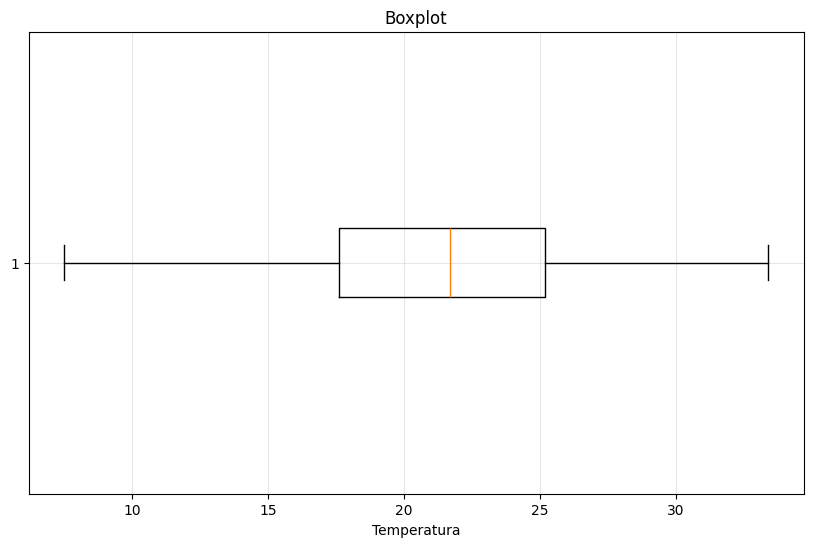

In [18]:
plt.figure(figsize=(10,6))

plt.boxplot(temperatura, vert=False)

plt.title('Boxplot')

plt.xlabel('Temperatura')

plt.grid(alpha=0.3)

plt.show()

In [19]:
print('BOXPLOT')

print('El boxplot muestra la mediana, los cuartiles y el rango intercuartilico.')

print('La caja representa la dispersion central de los datos.')

print('No se detectaron valores atipicos importantes en el conjunto de datos.')

print('La posicion de la mediana sugiere una distribucion relativamente equilibrada.')

BOXPLOT
El boxplot muestra la mediana, los cuartiles y el rango intercuartilico.
La caja representa la dispersion central de los datos.
No se detectaron valores atipicos importantes en el conjunto de datos.
La posicion de la mediana sugiere una distribucion relativamente equilibrada.


# Analisis de tendencias

In [20]:
# Convertir columna de periodo a fecha

datos['PERIODO'] = pd.to_datetime(datos['PERIODO'])

print(datos[['PERIODO']].head())

     PERIODO
0 1985-01-01
1 1985-01-01
2 1985-01-01
3 1985-01-01
4 1985-01-01


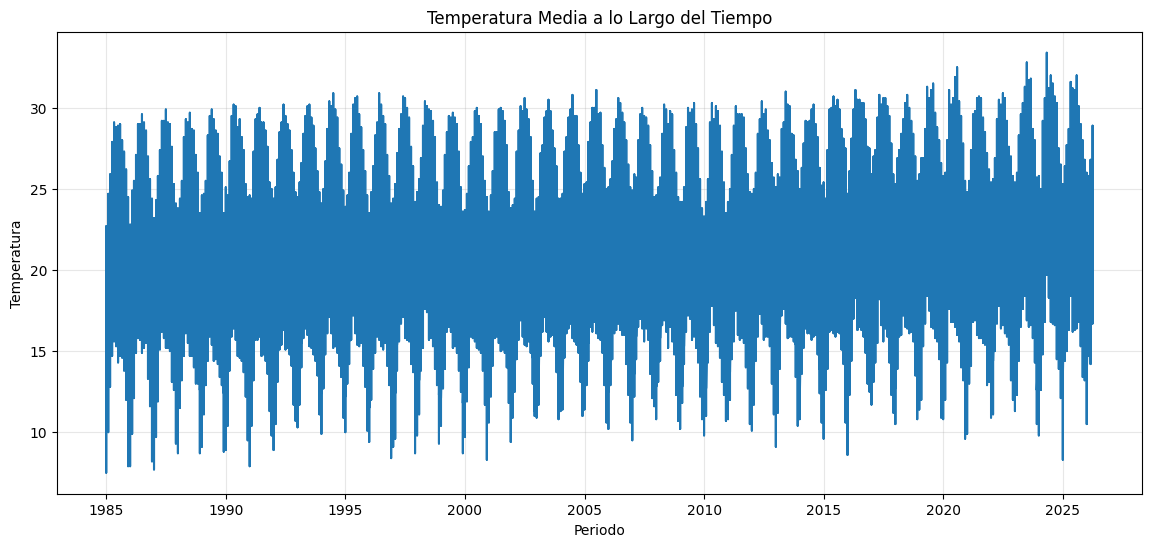

In [21]:
plt.figure(figsize=(14,6))

plt.plot(datos['PERIODO'], datos['MEDIA'])

plt.title('Temperatura Media a lo Largo del Tiempo')

plt.xlabel('Periodo')

plt.ylabel('Temperatura')

plt.grid(alpha=0.3)

plt.show()

In [22]:
print('TENDENCIAS')

print('La grafica temporal permite observar el comportamiento de la temperatura a lo largo del tiempo.')

print('Se identifican variaciones periodicas relacionadas con cambios estacionales.')

print('En ciertos periodos se observan incrementos y disminuciones de temperatura.')

print('El comportamiento general muestra estabilidad moderada con fluctuaciones normales.')

TENDENCIAS
La grafica temporal permite observar el comportamiento de la temperatura a lo largo del tiempo.
Se identifican variaciones periodicas relacionadas con cambios estacionales.
En ciertos periodos se observan incrementos y disminuciones de temperatura.
El comportamiento general muestra estabilidad moderada con fluctuaciones normales.


# Comentarios y conclusiones

In [ ]:
print('CONCLUSIONES')

print('1. El analisis estadistico nos permitio entender la distribucion de las temperaturas medias registradas.')

print('2. La media y la mediana presentaron valores cercanos, aunque existe un ligero tendencia hacia la izquierda.')

print('3. La desviacion estandar marca una dispersion moderada de los datos climaticos.')

print('4. No se encontraron valores atipicos significativos dentro del conjunto de datos.')

print('5. El histograma y la grafica de densidad permitieron identificar la concentracion principal de temperaturas.')

print('6. El boxplot confirmo la estabilidad general de los datos y la ausencia de outliers extremos.')

print('7. La grafica temporal mostro cambios periodicos relacionados con variaciones climaticas y estacionales.')

print('8. Este tipo de analisis puede ser util para estudios climaticos, ambientales y meteorologicos.')

print('9. Una limitacion del dataset es la posible existencia de datos faltantes o registros generales por entidad.')

print('10. Como mejora futura se podria realizar un analisis mas especifico por estados o temporadas.')

CONCLUSIONES
1. El analisis estadistico permitio comprender la distribucion de las temperaturas medias registradas.
2. La media y la mediana presentan valores cercanos, aunque existe un ligero sesgo hacia la izquierda.
3. La desviacion estandar indica una dispersion moderada de los datos climaticos.
4. No se encontraron valores atipicos significativos dentro del conjunto de datos.
5. El histograma y la grafica de densidad permitieron identificar la concentracion principal de temperaturas.
6. El boxplot confirmo la estabilidad general de los datos y la ausencia de outliers extremos.
7. La grafica temporal mostro cambios periodicos relacionados con variaciones climaticas y estacionales.
8. Este tipo de analisis puede ser util para estudios climaticos, ambientales y meteorologicos.
9. Una limitacion del dataset es la posible existencia de datos faltantes o registros generales por entidad.
10. Como mejora futura se podria realizar un analisis mas especifico por estados o temporadas.
